# Capítulo 21 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 21. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

sigma_SB, S0 = 5.67e-8, 1361.0

## T1 — Álgebra de feedbacks

**Solução.** Forçante $\Delta F$ produz resposta $\Delta T = \lambda_0\Delta F$ sem feedbacks (resposta de Planck). Um feedback devolve $f\,\Delta T$ à forçante; somando a série geométrica:
$$\Delta T = \frac{\lambda_0\,\Delta F}{1 - f},\qquad f = \sum_i f_i.$$
- $0 < f < 1$: amplificação (vapor d'água ~+0,4; gelo-albedo ~+0,1–0,2; nuvens: incerto);
- $f \to 1$: fuga (runaway) — o gelo-albedo do Caso 1 na região de múltiplos equilíbrios;
- $f < 0$: amortecimento (Planck já está em $\lambda_0$; Daisyworld é um $f<0$ biológico).
É a mesma álgebra do amplificador realimentado da eletrônica. ∎

## T2 — A resposta de Planck

In [2]:
T, F, eps = sp.symbols('T F epsilon', positive=True)
s = sp.Symbol('sigma', positive=True)
# OLR = eps sigma T^4; dT/dF = 1/(4 eps sigma T³)
lam0 = 1/sp.diff(eps*s*T**4, T)
display(sp.Eq(sp.Symbol('lambda_0'), lam0))
val = float(lam0.subs({eps: 0.62, s: sigma_SB, T: 288.0}))
print(f'lambda_0 = {val:.2f} K/(W/m²); com dF(2xCO2) = 3,7 W/m²:')
print(f'dT_Planck = {val*3.7:.1f} K — o famoso ~1,2 K sem feedbacks.')
print('Com f ~ 0,5-0,7 (vapor+gelo+nuvens): dT = 1,2/(1-f) ~ 2,5-4 K —')
print('a faixa de sensibilidade climatica do IPCC sai de UMA derivada + T1.')

Eq(lambda_0, 1/(4*T**3*epsilon*sigma))

lambda_0 = 0.30 K/(W/m²); com dF(2xCO2) = 3,7 W/m²:
dT_Planck = 1.1 K — o famoso ~1,2 K sem feedbacks.
Com f ~ 0,5-0,7 (vapor+gelo+nuvens): dT = 1,2/(1-f) ~ 2,5-4 K —
a faixa de sensibilidade climatica do IPCC sai de UMA derivada + T1.


## T3 — Por que 65°N no verão?

**Solução.** Mantos de gelo crescem onde a neve de inverno **sobrevive ao verão** — e isso é decidido pela insolação de verão nas latitudes dos continentes glaciáveis (65°N: Canadá, Escandinávia, Sibéria; o HS não tem terra equivalente fora da Antártida já gelada). Períodos: precessão (~23/19 ka) muda QUAL estação coincide com o periélio; obliquidade (~41 ka) muda o contraste sazonal; excentricidade (~100/413 ka) modula a amplitude da precessão. A resposta do gelo é lenta e não linear (Caso 1!), transformando o metrônomo linear em serra assimétrica de ~100 ka — glaciação lenta, deglaciação abrupta. ∎

## T4 — Estabilidade do Daisyworld

**Solução.** Perto do equilíbrio, uma perturbação $+\delta T$ favorece as margaridas brancas (mais perto do ótimo delas) e desfavorece as pretas → albedo planetário sobe → $T$ cai: a resposta se opõe à perturbação, $dA/dT > 0 \Rightarrow$ feedback negativo. Formalmente, o jacobiano do sistema (a_b, a_p) no equilíbrio interior tem traço negativo e determinante positivo → nó/foco estável. A regulação falha nas bordas (Sol fraco demais ou forte demais para qualquer margarida) — os colapsos abruptos do Caso 3. Moral: feedback biológico pode regular sem teleologia. ∎

## T5 — O período do oscilador ENSO

In [3]:
a_, b_, c_, d_ = sp.symbols('a b c d', positive=True)
M = sp.Matrix([[a_, b_], [-c_, -d_]])
lam = M.eigenvals()
for k in lam:
    display(sp.simplify(k))
print('λ = [(a-d) ± sqrt((a+d)² - 4bc)]/2: oscila quando bc > (a+d)²/4,')
print('com frequencia ω = sqrt(bc - (a-d)²/4) e crescimento (a-d)/2.')
vals = {a_: 0.7, b_: 1.4, c_: 1.6, d_: 0.3}
lamn = [complex(sp.N(k.subs(vals))) for k in lam]
print(f'com (0,7, 1,4, 1,6, 0,3): λ = {lamn[0]:.2f} -> período {2*np.pi/abs(lamn[0].imag):.1f} anos ✓')
print('a nao-linearidade (termo -T³) satura o crescimento; o ruido atmosferico')
print('(tempo!) torna os eventos irregulares — clima previsivel, tempo nao (Cap. 20).')

a/2 - d/2 - sqrt(a**2 + 2*a*d - 4*b*c + d**2)/2

a/2 - d/2 + sqrt(a**2 + 2*a*d - 4*b*c + d**2)/2

λ = [(a-d) ± sqrt((a+d)² - 4bc)]/2: oscila quando bc > (a+d)²/4,
com frequencia ω = sqrt(bc - (a-d)²/4) e crescimento (a-d)/2.
com (0,7, 1,4, 1,6, 0,3): λ = 0.20-1.41j -> período 4.5 anos ✓
a nao-linearidade (termo -T³) satura o crescimento; o ruido atmosferico
(tempo!) torna os eventos irregulares — clima previsivel, tempo nao (Cap. 20).


---
## N1 — O resgate vulcânico da bola de neve

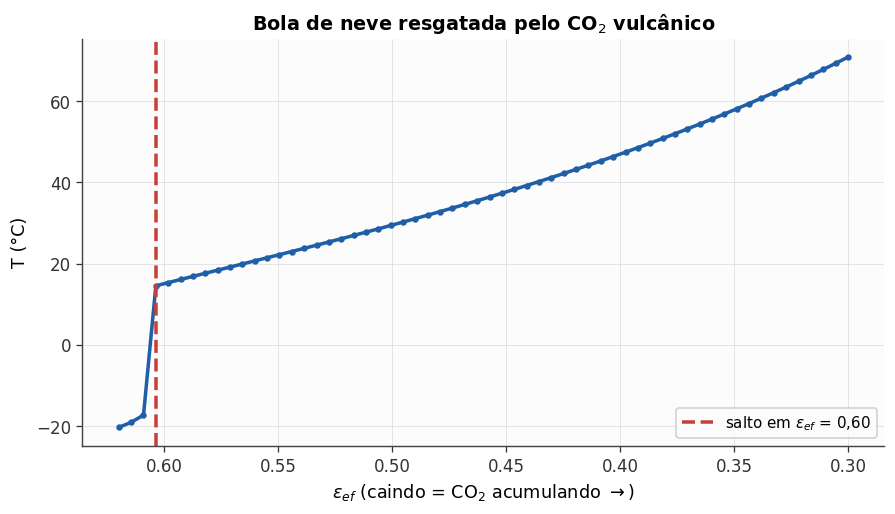

o planeta salta de -17 °C para 15 °C:
deglaciacao CATASTROFICA (e o registro geologico mostra carbonatos de capa
sobre depositos glaciais tropicais — a assinatura do salto).


In [4]:
def albedo(T):
    return 0.6 - 0.3*(1 + np.tanh((T - 268.0)/12.0))/2

def T_eq(eps_ef, T_ini):
    s = solve_ivp(lambda t, T: (S0/4*(1 - albedo(T[0])) - eps_ef*sigma_SB*T[0]**4)/4e8,
                  [0, 3e11], [T_ini], rtol=1e-8)
    return s.y[0][-1]

epss = np.linspace(0.62, 0.30, 60)              # CO2 acumulando => eps_ef caindo
Ts = []
T_atual = 220.0                                  # comeca congelado
for e in epss:
    T_atual = T_eq(e, T_atual)
    Ts.append(T_atual)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(epss, np.array(Ts) - 273.15, 'o-', ms=3, color=CORES['azul'])
isalto = np.argmax(np.diff(Ts) > 20)
ax.axvline(epss[isalto + 1], color=CORES['vermelho'], ls='--',
           label=f'salto em $\\varepsilon_{{ef}}$ = {epss[isalto+1]:.2f}'.replace('.', ','))
ax.invert_xaxis()
ax.set(xlabel='$\\varepsilon_{ef}$ (caindo = CO$_2$ acumulando $\\to$)',
       ylabel='T (°C)', title='Bola de neve resgatada pelo CO$_2$ vulcânico')
ax.legend()
plt.show()
print(f'o planeta salta de {Ts[isalto] - 273.15:.0f} °C para {Ts[isalto+1] - 273.15:.0f} °C:')
print('deglaciacao CATASTROFICA (e o registro geologico mostra carbonatos de capa')
print('sobre depositos glaciais tropicais — a assinatura do salto).')

## N2 — O gelo lento retifica Milankovitch

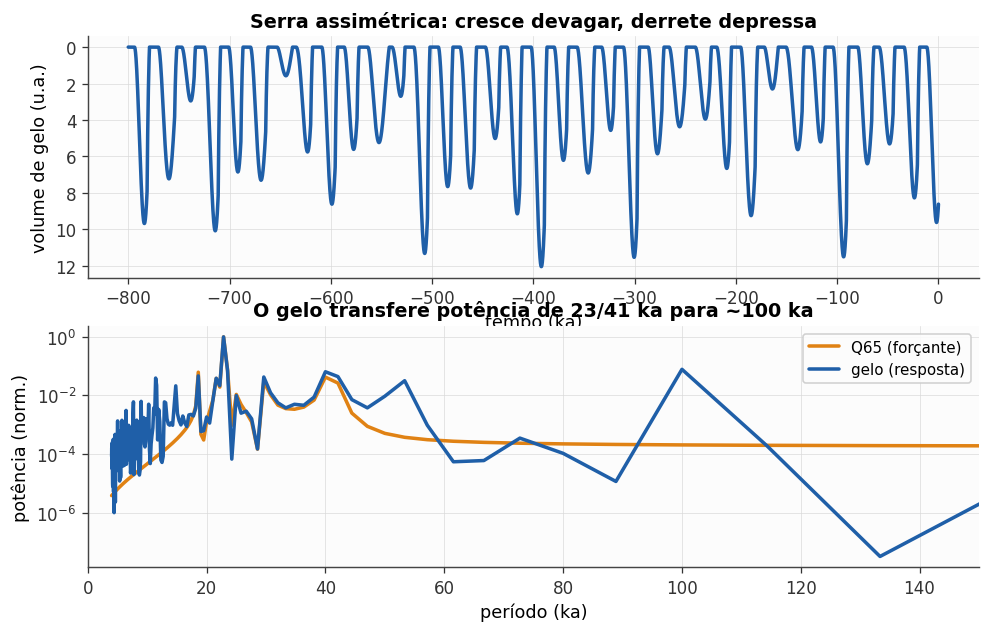

a forcante quase nao tem 100 ka, mas a RESPOSTA tem: nao-linearidade +
memoria lenta retificam o metronomo — a resolucao moderna do misterio.


In [5]:
t_ka = np.linspace(-800, 0, 8000)
dt = t_ka[1] - t_ka[0]
ecc = 0.028 + 0.012*np.cos(2*np.pi*t_ka/100) + 0.006*np.cos(2*np.pi*t_ka/413)
obliq = 23.3 + 1.2*np.cos(2*np.pi*t_ka/41)
prec = ecc*np.sin(2*np.pi*t_ka/23)
Q65 = 12*(obliq - 23.3) + 55*prec/0.028

# gelo: integra -Q65 com memoria tau e derrete rapido acima de limiar
V = np.zeros(t_ka.size)
tau, lim = 12.0, 25.0
for k in range(t_ka.size - 1):
    cresce = -Q65[k]/40 - V[k]/tau
    if Q65[k] > lim and V[k] > 0:
        cresce -= V[k]*0.6                       # deglaciacao rapida
    V[k+1] = max(V[k] + cresce*dt, 0)

from numpy.fft import rfft, rfftfreq
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
ax1.plot(t_ka, V, color=CORES['azul'])
ax1.invert_yaxis()
ax1.set(xlabel='tempo (ka)', ylabel='volume de gelo (u.a.)',
        title='Serra assimétrica: cresce devagar, derrete depressa')
for serie, cor, nome in [(Q65, CORES['laranja'], 'Q65 (forçante)'),
                          (V, CORES['azul'], 'gelo (resposta)')]:
    S = np.abs(rfft(serie - serie.mean()))**2
    f = rfftfreq(serie.size, dt)
    ax2.semilogy(1/f[1:200], S[1:200]/S.max(), color=cor, label=nome)
ax2.set(xlabel='período (ka)', ylabel='potência (norm.)', xlim=(0, 150),
        title='O gelo transfere potência de 23/41 ka para ~100 ka')
ax2.legend()
plt.show()
print('a forcante quase nao tem 100 ka, mas a RESPOSTA tem: nao-linearidade +')
print('memoria lenta retificam o metronomo — a resolucao moderna do misterio.')

## N3 — Diversidade e regulação

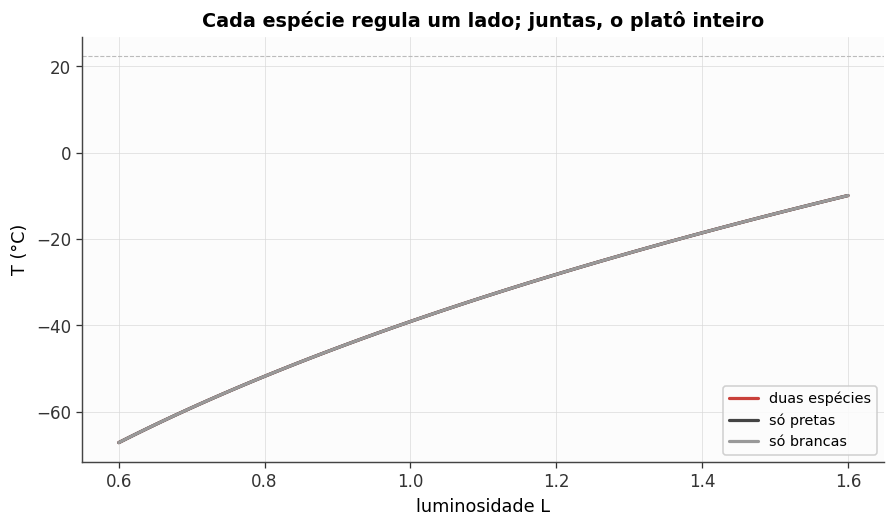

pretas seguram o lado frio (Sol fraco); brancas o lado quente: a
diversidade ESTENDE o intervalo regulado — resiliencia por variedade,
um resultado geral de sistemas com feedbacks complementares.


In [6]:
A_solo, A_br, A_pr = 0.5, 0.75, 0.25
T_opt, k_larg, q_loc, gamma_m = 295.5, 17.5**(-2), 20.0, 0.3

def daisy(t, y, L, so_uma=None):
    ab, ap = np.clip(y, 0, 1)
    if so_uma == 'pr': ab = 0.0
    if so_uma == 'br': ap = 0.0
    x = max(1 - ab - ap, 0)
    A = A_solo*x + A_br*ab + A_pr*ap
    T = (L*S0/4*(1 - A)/sigma_SB)**0.25
    Tb = T + q_loc*(A - A_br); Tp = T + q_loc*(A - A_pr)
    bb = max(1 - k_larg*(T_opt - Tb)**2, 0)
    bp = max(1 - k_larg*(T_opt - Tp)**2, 0)
    return [ab*(x*bb - gamma_m), ap*(x*bp - gamma_m)]

def curva_T(so_uma):
    Ls = np.linspace(0.6, 1.6, 100)
    Ts = []
    y = [0.01, 0.01]
    for L in Ls:
        s = solve_ivp(daisy, [0, 300], y, args=(L, so_uma), rtol=1e-8)
        ab, ap = np.clip(s.y[:, -1], 0, 1)
        if so_uma == 'pr': ab = 0.0
        if so_uma == 'br': ap = 0.0
        y = [max(ab, 0.01), max(ap, 0.01)]
        x = max(1 - ab - ap, 0)
        A = A_solo*x + A_br*ab + A_pr*ap
        Ts.append((L*S0/4*(1 - A)/sigma_SB)**0.25 - 273.15)
    return Ls, np.array(Ts)

fig, ax = plt.subplots(figsize=(9, 4.8))
for so, cor, nome in [(None, CORES['vermelho'], 'duas espécies'),
                       ('pr', '#444444', 'só pretas'),
                       ('br', '#999999', 'só brancas')]:
    Ls, Ts = curva_T(so)
    ax.plot(Ls, Ts, color=cor, lw=2, label=nome)
ax.axhline(T_opt - 273.15, color='#bbbbbb', lw=0.7, ls='--')
ax.set(xlabel='luminosidade L', ylabel='T (°C)',
       title='Cada espécie regula um lado; juntas, o platô inteiro')
ax.legend(fontsize=9)
plt.show()
print('pretas seguram o lado frio (Sol fraco); brancas o lado quente: a')
print('diversidade ESTENDE o intervalo regulado — resiliencia por variedade,')
print('um resultado geral de sistemas com feedbacks complementares.')

## N4 — A bifurcação de Hopf do ENSO

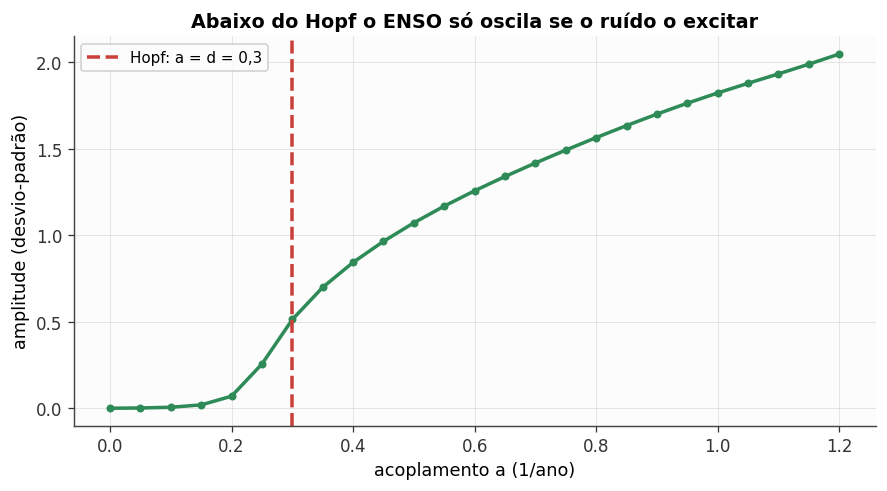

para a < d = 0.3 o ponto fixo e estavel (traço a-d < 0): sem ruido, nada;
COM ruido atmosferico o sistema sub-critico ainda oscila (oscilador
excitado por ruido) — o debate real "ENSO auto-sustentado ou excitado"
cabe inteiro neste grafico de brinquedo.


In [7]:
b, c, d = 1.4, 1.6, 0.3
rng = np.random.default_rng(4)

def roda(a, T_tot=120.0, ruido=0.0):
    dt = 1/36
    n = int(T_tot/dt)
    T = np.zeros(n); h = np.zeros(n); T[0] = 0.5
    for k in range(n - 1):
        T[k+1] = T[k] + (a*T[k] + b*h[k] - 0.15*T[k]**3)*dt \
                 + ruido*rng.standard_normal()*np.sqrt(dt)
        h[k+1] = h[k] + (-c*T[k] - d*h[k])*dt
    return T[n//3:]

a_s = np.linspace(0.0, 1.2, 25)
amp = [np.std(roda(a)) for a in a_s]
a_hopf = d  # traço = a - d = 0

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(a_s, amp, 'o-', ms=4, color=CORES['verde'])
ax.axvline(a_hopf, color=CORES['vermelho'], ls='--',
           label=f'Hopf: a = d = {d}'.replace('.', ','))
ax.set(xlabel='acoplamento a (1/ano)', ylabel='amplitude (desvio-padrão)',
       title='Abaixo do Hopf o ENSO só oscila se o ruído o excitar')
ax.legend()
plt.show()
print(f'para a < d = {d} o ponto fixo e estavel (traço a-d < 0): sem ruido, nada;')
print('COM ruido atmosferico o sistema sub-critico ainda oscila (oscilador')
print('excitado por ruido) — o debate real "ENSO auto-sustentado ou excitado"')
print('cabe inteiro neste grafico de brinquedo.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*